ORIGA DATASET MY CODE(EARLIER VERSION) 2 KAN BLOCKS

In [30]:
# Cell 0: Environment setup
!pip install -q albumentations opencv-python-headless

import os, cv2, glob, random, math
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [31]:
# Cell 1: Kaggle API authentication
from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

Upload your kaggle.json file now:


Saving kaggle.json to kaggle (1).json


In [33]:
# Cell 2: Download glaucoma datasets
!kaggle datasets download -d arnavjain1/glaucoma-datasets -p /content/data --unzip

Dataset URL: https://www.kaggle.com/datasets/arnavjain1/glaucoma-datasets
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100% 5.55G/5.55G [04:39<00:00, 21.3MB/s]



In [32]:
# Cell 3: Explore ORIGA folder structure
import os

for root, dirs, files in os.walk("/content/data/ORIGA"):
    level = root.replace("/content/data/ORIGA", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for f in files[:3]:  # show just first 3 files as sample
            print(f"{'  '*(level+1)}{f}")

ORIGA/
  OrigaList.csv
  origa_info.csv
  Semi-automatic-annotations/
    287.mat
    109.mat
    424.mat
  Masks_Square/
    354.png
    138.png
    329.png
  Masks_Cropped/
    354.png
    138.png
    329.png
  Masks/
    354.png
    138.png
    329.png
  Images/
    548.jpg
    631.jpg
    040.jpg
  Images_Cropped/
    548.jpg
    631.jpg
    040.jpg
  Images_Square/
    548.jpg
    631.jpg
    040.jpg


In [34]:
# Cell 4: ORIGA paths + mask inspection
ORIGA_IMG_DIR  = "/content/data/ORIGA/Images_Cropped"
ORIGA_MASK_DIR = "/content/data/ORIGA/Masks_Cropped"

sample_files = sorted(os.listdir(ORIGA_MASK_DIR))[:5]
print("Sample mask files:", sample_files)
for f in sample_files:
    m = cv2.imread(os.path.join(ORIGA_MASK_DIR, f), cv2.IMREAD_UNCHANGED)
    print(f, "-> shape:", m.shape, "| dtype:", m.dtype, "| unique values:", np.unique(m))

Sample mask files: ['001.png', '002.png', '003.png', '004.png', '005.png']
001.png -> shape: (465, 465) | dtype: uint8 | unique values: [0 1 2]
002.png -> shape: (443, 443) | dtype: uint8 | unique values: [0 1 2]
003.png -> shape: (404, 404) | dtype: uint8 | unique values: [0 1 2]
004.png -> shape: (374, 374) | dtype: uint8 | unique values: [0 1 2]
005.png -> shape: (391, 391) | dtype: uint8 | unique values: [0 1 2]


In [35]:
# Cell 5: 80/10/10 split
random.seed(42)
all_files = sorted(os.listdir(ORIGA_IMG_DIR))

matched = []
for f in all_files:
    stem = os.path.splitext(f)[0]
    for ext in [".png", ".bmp", ".jpg"]:
        mask_candidate = os.path.join(ORIGA_MASK_DIR, stem + ext)
        if os.path.exists(mask_candidate):
            matched.append((f, stem + ext))
            break

random.shuffle(matched)
n = len(matched)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)

train_files = matched[:n_train]
val_files   = matched[n_train:n_train+n_val]
test_files  = matched[n_train+n_val:]

print(f"Total: {n} | Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

Total: 650 | Train: 520 | Val: 65 | Test: 65


In [36]:
# Cell 6: Albumentations transforms
IMG_SIZE = 256

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [37]:
# Cell 7: Dataset class with remap support for ORIGA mask encoding
class GlaucomaDataset(Dataset):
    def __init__(self, img_dir, mask_dir, file_list, transform=None, remap_mask=True):
        self.img_dir    = img_dir
        self.mask_dir   = mask_dir
        self.transform  = transform
        self.remap      = remap_mask
        self.filenames  = file_list   # list of (img_filename, mask_filename) tuples

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name, mask_name = self.filenames[idx]
        image = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB
        )
        mask = cv2.imread(os.path.join(self.mask_dir, mask_name), cv2.IMREAD_UNCHANGED)

        # Remap [0, 128, 255] -> [0, 1, 2] for PyTorch compatibility
        if self.remap:
            remapped = np.zeros_like(mask, dtype=np.uint8)
            remapped[mask == 128] = 1   # optic cup
            remapped[mask == 255] = 2   # optic disc
            mask = remapped

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image, mask = aug['image'], aug['mask']

        return image, mask.long()

In [39]:
# Cell 8: DataLoaders
# SET THESE based on Cell 4 output:
NUM_CLASSES = 3      # 3 if unique=[0,128,255] or [0,1,2] | 2 if unique=[0,255]
REMAP_MASK  = False   # True if unique=[0,128,255] | False if already [0,1,2]

CLASS_NAMES = ["Background", "Optic Cup", "Optic Disc"]  # adjust if NUM_CLASSES=2

train_ds = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, train_files,
                           transform=train_transform, remap_mask=REMAP_MASK)
val_ds   = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, val_files,
                           transform=val_transform,   remap_mask=REMAP_MASK)
test_ds  = GlaucomaDataset(ORIGA_IMG_DIR, ORIGA_MASK_DIR, test_files,
                           transform=val_transform,   remap_mask=REMAP_MASK)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
imgs, masks = next(iter(train_loader))
print("Batch shapes:", imgs.shape, masks.shape, "| mask unique:", torch.unique(masks))

Train: 520 | Val: 65 | Test: 65
Batch shapes: torch.Size([8, 3, 256, 256]) torch.Size([8, 256, 256]) | mask unique: tensor([0, 1, 2])


In [40]:
# Cell 9: KANLinear — 2 of these are used inside every KANBlock (fc1 + fc2)
class KANLinear(nn.Module):
    def __init__(self, in_features, out_features, grid_size=5, spline_order=3,
                 base_activation=nn.SiLU, grid_range=(-1, 1)):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.grid_size    = grid_size
        self.spline_order = spline_order

        h    = (grid_range[1] - grid_range[0]) / grid_size
        grid = torch.arange(-spline_order, grid_size + spline_order + 1) * h + grid_range[0]
        grid = grid.expand(in_features, -1).contiguous()
        self.register_buffer("grid", grid)

        self.base_weight   = nn.Parameter(torch.empty(out_features, in_features))
        self.spline_weight = nn.Parameter(
            torch.empty(out_features, in_features, grid_size + spline_order)
        )
        self.base_activation = base_activation()

        nn.init.kaiming_uniform_(self.base_weight, a=math.sqrt(5))
        nn.init.normal_(self.spline_weight, mean=0.0, std=0.1)

    def b_splines(self, x):
        grid  = self.grid
        x     = x.unsqueeze(-1)
        bases = ((x >= grid[:, :-1]) & (x < grid[:, 1:])).float()
        for k in range(1, self.spline_order + 1):
            left  = (x - grid[:, :-(k+1)]) / (grid[:, k:-1]   - grid[:, :-(k+1)])
            right = (grid[:, k+1:] - x)    / (grid[:, k+1:]   - grid[:, 1:-k])
            bases = left * bases[:, :, :-1] + right * bases[:, :, 1:]
        return bases

    def forward(self, x):
        orig_shape = x.shape
        x          = x.reshape(-1, self.in_features)
        base_out   = F.linear(self.base_activation(x), self.base_weight)
        spline_basis = self.b_splines(x)
        spline_out   = torch.einsum("bik,oik->bo", spline_basis, self.spline_weight)
        out = base_out + spline_out
        return out.reshape(*orig_shape[:-1], self.out_features)

In [41]:
# Cell 10: DWConv + KANBlock
# Each KANBlock has: LayerNorm -> KANLinear(fc1) -> DWConv -> GELU -> KANLinear(fc2) -> Dropout + residual
class DWConv(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, kernel_size=3, padding=1, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class KANBlock(nn.Module):
    """
    One KANBlock = 2 KANLinear layers (fc1 + fc2) with DWConv in between.
    fc1: dim -> hidden_dim
    fc2: hidden_dim -> dim
    Residual connection wraps the whole block.
    """
    def __init__(self, dim, hidden_dim=None, grid_size=5, spline_order=3, drop=0.0):
        super().__init__()
        hidden_dim   = hidden_dim or dim
        self.norm    = nn.LayerNorm(dim)
        self.fc1     = KANLinear(dim, hidden_dim, grid_size=grid_size, spline_order=spline_order)
        self.dwconv  = DWConv(hidden_dim)
        self.act     = nn.GELU()
        self.fc2     = KANLinear(hidden_dim, dim, grid_size=grid_size, spline_order=spline_order)
        self.drop    = nn.Dropout(drop)

    def forward(self, x, H, W):
        shortcut = x
        x = self.norm(x)
        x = self.fc1(x)           # KANLinear 1
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.fc2(x)           # KANLinear 2
        x = self.drop(x)
        return x + shortcut       # residual

In [42]:
# Cell 11: ConvBlock, PatchEmbed, tokens_to_map, UpConv
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.block(x)


class PatchEmbed(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1)
        self.norm = nn.LayerNorm(out_ch)
    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W


def tokens_to_map(x, H, W):
    B, N, C = x.shape
    return x.transpose(1, 2).reshape(B, C, H, W)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
    def forward(self, x): return self.conv(self.up(x))

In [43]:
# Cell 12: U-KAN model — architecture identical to G1020 run
class UKAN(nn.Module):
    def __init__(self, num_classes=3, in_ch=3,
                 conv_channels=(64, 128, 256), tok_channels=(320, 512),
                 grid_size=5, spline_order=3):
        super().__init__()
        C1, C2, C3 = conv_channels
        D1, D2     = tok_channels

        # Encoder — conv stages
        self.conv1 = ConvBlock(in_ch, C1)
        self.conv2 = ConvBlock(C1, C2)
        self.conv3 = ConvBlock(C2, C3)
        self.pool  = nn.MaxPool2d(2)

        # Encoder — KAN tokenizer stages
        self.patch_embed1 = PatchEmbed(C3, D1, stride=2)
        self.kan_enc1     = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)
        self.patch_embed2 = PatchEmbed(D1, D2, stride=2)
        self.kan_enc2     = KANBlock(D2, grid_size=grid_size, spline_order=spline_order)

        # Decoder — KAN stages
        self.up_tok1  = UpConv(D2, D1)
        self.kan_dec1 = KANBlock(D1, grid_size=grid_size, spline_order=spline_order)
        self.up_tok2  = UpConv(D1, C3)
        self.kan_dec2 = KANBlock(C3, grid_size=grid_size, spline_order=spline_order)

        # Decoder — conv stages
        self.up_conv1 = UpConv(C3, C3)
        self.dconv1   = ConvBlock(C3, C2)
        self.up_conv2 = UpConv(C2, C2)
        self.dconv2   = ConvBlock(C2, C1)
        self.up_conv3 = UpConv(C1, C1)
        self.dconv3   = ConvBlock(C1, C1)

        self.head = nn.Conv2d(C1, num_classes, kernel_size=1)

    def forward(self, x):
        # Conv encoder
        e1 = self.conv1(x);  p1 = self.pool(e1)
        e2 = self.conv2(p1); p2 = self.pool(e2)
        e3 = self.conv3(p2); p3 = self.pool(e3)

        # KAN encoder
        t1, H1, W1 = self.patch_embed1(p3)
        t1          = self.kan_enc1(t1, H1, W1)
        skip_tok1   = tokens_to_map(t1, H1, W1)

        t2, H2, W2 = self.patch_embed2(skip_tok1)
        t2          = self.kan_enc2(t2, H2, W2)
        b           = tokens_to_map(t2, H2, W2)

        # KAN decoder
        d_t1 = self.up_tok1(b) + skip_tok1
        B_, C_, H_, W_ = d_t1.shape
        d_t1 = tokens_to_map(
            self.kan_dec1(d_t1.flatten(2).transpose(1, 2), H_, W_), H_, W_
        )

        d_t2 = self.up_tok2(d_t1) + p3
        B_, C_, H_, W_ = d_t2.shape
        d_t2 = tokens_to_map(
            self.kan_dec2(d_t2.flatten(2).transpose(1, 2), H_, W_), H_, W_
        )

        # Conv decoder with skip connections
        d1 = self.dconv1(self.up_conv1(d_t2) + e3)
        d2 = self.dconv2(self.up_conv2(d1)   + e2)
        d3 = self.dconv3(self.up_conv3(d2)   + e1)

        return self.head(d3)

In [44]:
# Cell 13: Forward pass sanity check
model = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
dummy = torch.randn(4, 3, 256, 256).to(DEVICE)
out   = model(dummy)
print("Output shape:", out.shape)   # expect [4, NUM_CLASSES, 256, 256]
print("Total trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Output shape: torch.Size([4, 3, 256, 256])
Total trainable params: 16578499


In [45]:
# Cell 14: Dice + Combined loss
class DiceLoss(nn.Module):
    def __init__(self, num_classes, smooth=1e-6):
        super().__init__()
        self.num_classes = num_classes
        self.smooth      = smooth

    def forward(self, logits, targets):
        probs          = F.softmax(logits, dim=1)
        targets_onehot = F.one_hot(targets, self.num_classes).permute(0,3,1,2).float()
        dims           = (0, 2, 3)
        intersection   = torch.sum(probs * targets_onehot, dims)
        union          = torch.sum(probs + targets_onehot, dims)
        dice_per_class = (2.*intersection + self.smooth) / (union + self.smooth)
        return 1 - dice_per_class.mean()


class CombinedLoss(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.ce   = nn.CrossEntropyLoss()
        self.dice = DiceLoss(num_classes)

    def forward(self, logits, targets):
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)

In [46]:
# Cell 15: All metrics — Accuracy, Dice, IoU, Precision, Recall, F1 per class
@torch.no_grad()
def compute_all_metrics(logits, targets, num_classes, smooth=1e-6):
    preds   = torch.argmax(logits, dim=1)
    metrics = {"dice": [], "iou": [], "precision": [], "recall": [], "f1": []}

    for c in range(num_classes):
        pred_c   = (preds == c)
        target_c = (targets == c)
        tp = (pred_c &  target_c).sum().float()
        fp = (pred_c & ~target_c).sum().float()
        fn = (~pred_c & target_c).sum().float()

        precision = (tp + smooth) / (tp + fp + smooth)
        recall    = (tp + smooth) / (tp + fn + smooth)
        f1        = (2 * precision * recall) / (precision + recall + smooth)
        dice      = (2*tp + smooth) / (2*tp + fp + fn + smooth)
        iou       = (tp + smooth)   / (tp + fp + fn + smooth)

        metrics["dice"].append(dice.item())
        metrics["iou"].append(iou.item())
        metrics["precision"].append(precision.item())
        metrics["recall"].append(recall.item())
        metrics["f1"].append(f1.item())

    metrics["accuracy"] = (preds == targets).float().mean().item()
    return metrics

In [47]:
# Cell 16: Full evaluation over a DataLoader
def evaluate_full(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    agg = {k: np.zeros(num_classes) for k in ["dice","iou","precision","recall","f1"]}
    agg["accuracy"] = 0.0
    n_batches = 0

    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs       = model(images)
            running_loss += criterion(outputs, masks).item() * images.size(0)
            m             = compute_all_metrics(outputs, masks, num_classes)
            for k in ["dice","iou","precision","recall","f1"]:
                agg[k] += np.array(m[k])
            agg["accuracy"] += m["accuracy"]
            n_batches += 1

    for k in ["dice","iou","precision","recall","f1"]:
        agg[k] /= n_batches
    agg["accuracy"] /= n_batches
    return running_loss / len(loader.dataset), agg

In [48]:
# Cell 17: Full training loop — tracks every metric every epoch
def train_model_full(model, train_loader, val_loader, num_classes,
                     num_epochs=100, patience=15, lr=1e-3,
                     save_path="/content/best_ukan_origa.pth"):

    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion  = CombinedLoss(num_classes=num_classes)

    best_mean_dice, epochs_no_improve = 0.0, 0

    # History stores train loss + all val metrics
    history = {"train_loss": [], "val_loss": [], "val_accuracy": []}
    for k in ["dice","iou","precision","recall","f1"]:
        for c in range(num_classes):
            history[f"val_{k}_class{c}"] = []

    for epoch in range(1, num_epochs+1):
        # ---- Training ----
        model.train()
        running_loss = 0.0
        for images, masks in train_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        # ---- Validation ----
        val_loss, agg = evaluate_full(model, val_loader, criterion, DEVICE, num_classes)
        scheduler.step()

        # ---- Store history ----
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(agg["accuracy"])
        for k in ["dice","iou","precision","recall","f1"]:
            for c in range(num_classes):
                history[f"val_{k}_class{c}"].append(agg[k][c])

        mean_dice = np.mean(agg["dice"][1:]) if num_classes > 1 else agg["dice"][0]

        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"TrainLoss:{train_loss:.4f} | ValLoss:{val_loss:.4f} | "
              f"Acc:{agg['accuracy']:.4f} | "
              f"Dice:{np.round(agg['dice'],3)} | "
              f"IoU:{np.round(agg['iou'],3)} | "
              f"Prec:{np.round(agg['precision'],3)} | "
              f"Rec:{np.round(agg['recall'],3)} | "
              f"F1:{np.round(agg['f1'],3)} | "
              f"MeanDice(fg):{mean_dice:.4f}")

        # ---- Early stopping + save best ----
        if mean_dice > best_mean_dice:
            best_mean_dice, epochs_no_improve = mean_dice, 0
            torch.save(model.state_dict(), save_path)
            print(f"  -> Best model saved | MeanDice: {best_mean_dice:.4f}")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch}")
                break

    return history

In [49]:
# Cell 18: Train on ORIGA
model_origa   = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
history_origa = train_model_full(
    model_origa, train_loader, val_loader,
    num_classes=NUM_CLASSES,
    save_path="/content/best_ukan_origa.pth"
)

Epoch   1/100 | TrainLoss:0.4234 | ValLoss:0.4028 | Acc:0.8113 | Dice:[0.817 0.791 0.836] | IoU:[0.692 0.657 0.721] | Prec:[0.983 0.774 0.761] | Rec:[0.701 0.81  0.93 ] | F1:[0.817 0.791 0.836] | MeanDice(fg):0.8133
  -> Best model saved | MeanDice: 0.8133
Epoch   2/100 | TrainLoss:0.3238 | ValLoss:0.4855 | Acc:0.7480 | Dice:[0.828 0.724 0.673] | IoU:[0.708 0.568 0.508] | Prec:[0.717 0.704 0.973] | Rec:[0.984 0.746 0.516] | F1:[0.828 0.724 0.673] | MeanDice(fg):0.6981
Epoch   3/100 | TrainLoss:0.3064 | ValLoss:0.3144 | Acc:0.8320 | Dice:[0.84  0.821 0.842] | IoU:[0.725 0.698 0.73 ] | Prec:[0.989 0.777 0.813] | Rec:[0.731 0.871 0.877] | F1:[0.84  0.821 0.842] | MeanDice(fg):0.8313
  -> Best model saved | MeanDice: 0.8313
Epoch   4/100 | TrainLoss:0.2942 | ValLoss:0.2892 | Acc:0.8507 | Dice:[0.907 0.837 0.807] | IoU:[0.83  0.721 0.678] | Prec:[0.863 0.806 0.931] | Rec:[0.957 0.871 0.712] | F1:[0.907 0.837 0.807] | MeanDice(fg):0.8219
Epoch   5/100 | TrainLoss:0.2834 | ValLoss:0.2710 | Ac

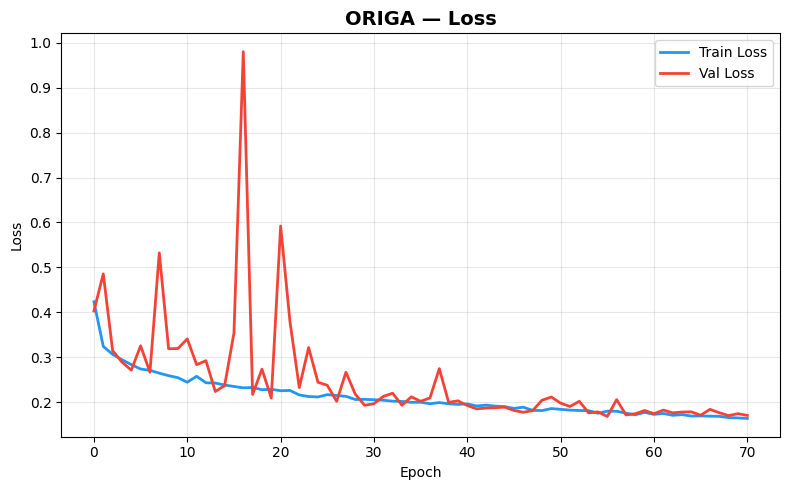

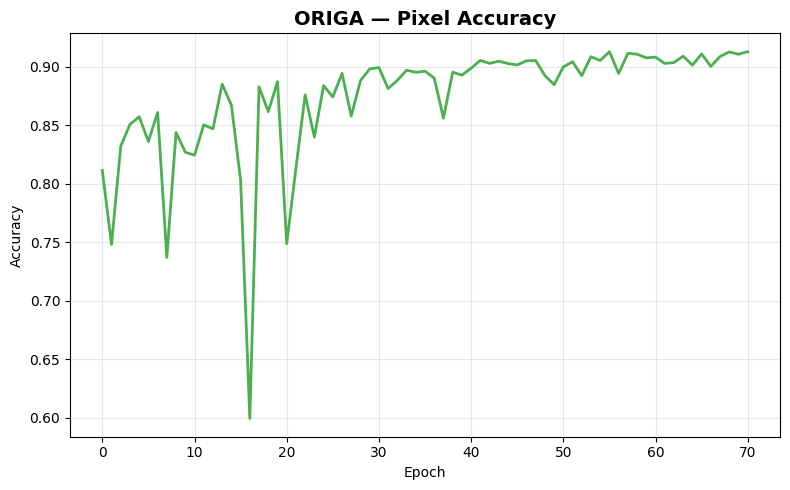

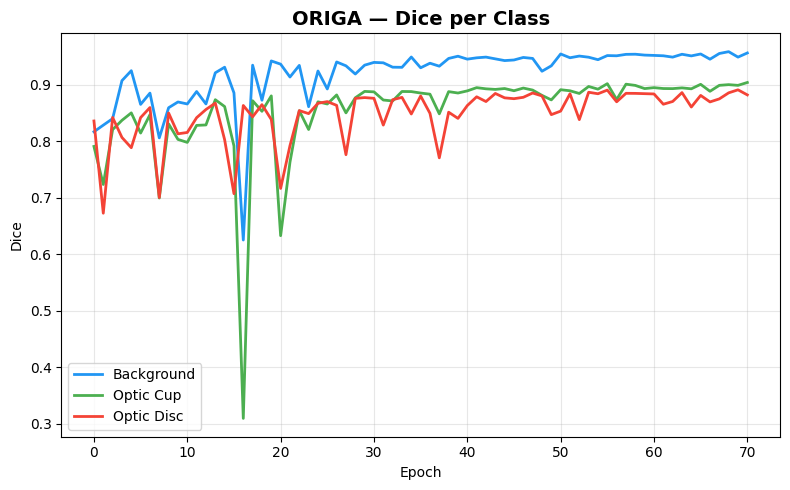

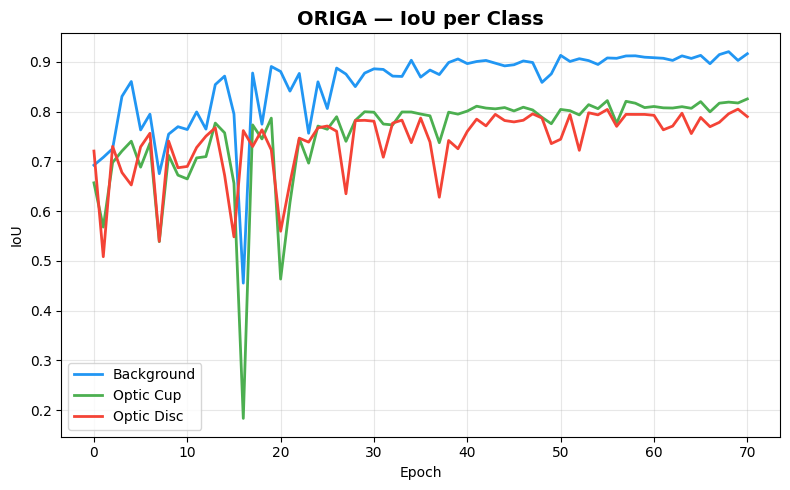

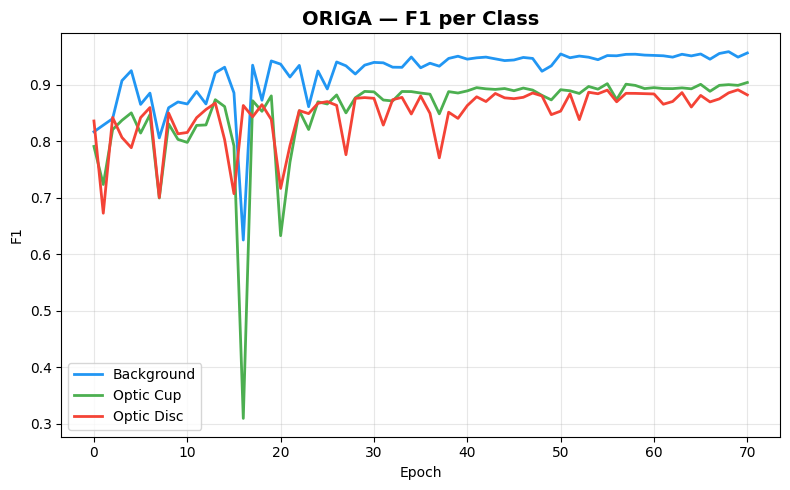

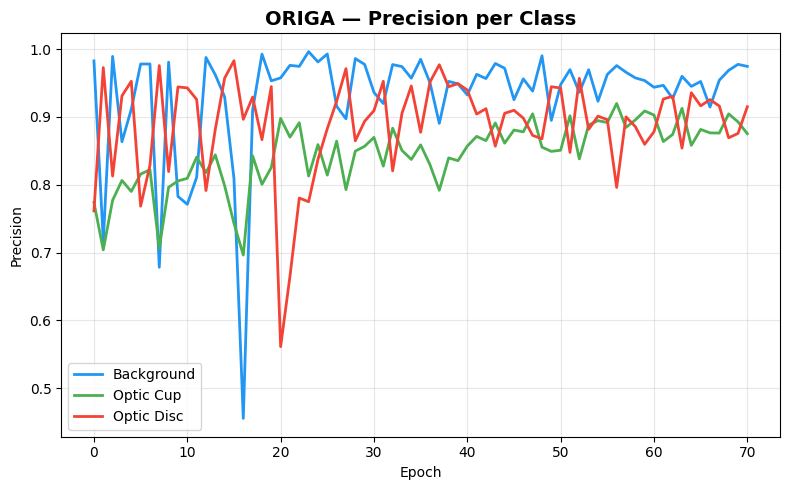

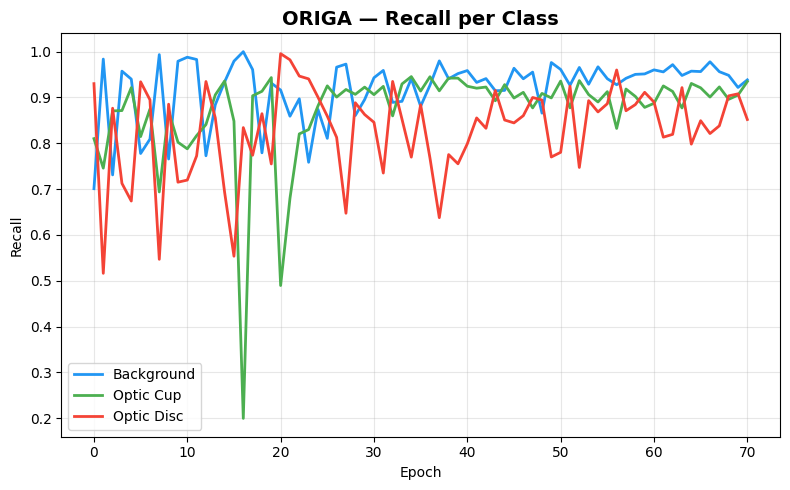

All 7 graphs saved to /content/ORIGA_*.png


In [50]:
# Cell 19: Separate graph for every metric — Loss, Accuracy, Dice, IoU, F1, Precision, Recall
def plot_all_curves_separate(history, num_classes, class_names, prefix="ORIGA"):
    COLORS = ["#2196F3", "#4CAF50", "#F44336", "#FF9800", "#9C27B0"]

    # 1. Loss
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["train_loss"], label="Train Loss", color="#2196F3", linewidth=2)
    ax.plot(history["val_loss"],   label="Val Loss",   color="#F44336", linewidth=2)
    ax.set_title(f"{prefix} — Loss", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_loss.png", dpi=120); plt.show()

    # 2. Accuracy
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history["val_accuracy"], color="#4CAF50", linewidth=2)
    ax.set_title(f"{prefix} — Pixel Accuracy", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_accuracy.png", dpi=120); plt.show()

    # 3. Dice per class
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(num_classes):
        ax.plot(history[f"val_dice_class{c}"], label=class_names[c],
                color=COLORS[c], linewidth=2)
    ax.set_title(f"{prefix} — Dice per Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Dice"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_dice.png", dpi=120); plt.show()

    # 4. IoU per class
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(num_classes):
        ax.plot(history[f"val_iou_class{c}"], label=class_names[c],
                color=COLORS[c], linewidth=2)
    ax.set_title(f"{prefix} — IoU per Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("IoU"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_iou.png", dpi=120); plt.show()

    # 5. F1 per class
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(num_classes):
        ax.plot(history[f"val_f1_class{c}"], label=class_names[c],
                color=COLORS[c], linewidth=2)
    ax.set_title(f"{prefix} — F1 per Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("F1"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_f1.png", dpi=120); plt.show()

    # 6. Precision per class (SEPARATE)
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(num_classes):
        ax.plot(history[f"val_precision_class{c}"], label=class_names[c],
                color=COLORS[c], linewidth=2)
    ax.set_title(f"{prefix} — Precision per Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Precision"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_precision.png", dpi=120); plt.show()

    # 7. Recall per class (SEPARATE)
    fig, ax = plt.subplots(figsize=(8, 5))
    for c in range(num_classes):
        ax.plot(history[f"val_recall_class{c}"], label=class_names[c],
                color=COLORS[c], linewidth=2)
    ax.set_title(f"{prefix} — Recall per Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Epoch"); ax.set_ylabel("Recall"); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(f"/content/{prefix}_recall.png", dpi=120); plt.show()

    print(f"All 7 graphs saved to /content/{prefix}_*.png")

plot_all_curves_separate(history_origa, NUM_CLASSES, CLASS_NAMES, prefix="ORIGA")

In [51]:
# Cell 20: Load best model + full test evaluation
best_model = UKAN(num_classes=NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(torch.load("/content/best_ukan_origa.pth"))

test_loss, test_metrics = evaluate_full(
    best_model, test_loader, CombinedLoss(NUM_CLASSES), DEVICE, NUM_CLASSES
)

print("\n" + "="*55)
print("         ORIGA TEST SET RESULTS — U-KAN")
print("="*55)
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Pixel Accuracy: {test_metrics['accuracy']:.4f}")
print()
for k in ["dice","iou","precision","recall","f1"]:
    vals = test_metrics[k]
    for c, name in enumerate(CLASS_NAMES):
        print(f"  {k.capitalize():10s} [{name:12s}]: {vals[c]:.4f}")
    print(f"  {k.capitalize():10s} [Mean FG     ]: {np.mean(vals[1:]):.4f}")
    print()
print("="*55)


         ORIGA TEST SET RESULTS — U-KAN
  Test Loss     : 0.1672
  Pixel Accuracy: 0.9109

  Dice       [Background  ]: 0.9499
  Dice       [Optic Cup   ]: 0.9017
  Dice       [Optic Disc  ]: 0.8840
  Dice       [Mean FG     ]: 0.8928

  Iou        [Background  ]: 0.9048
  Iou        [Optic Cup   ]: 0.8216
  Iou        [Optic Disc  ]: 0.7929
  Iou        [Mean FG     ]: 0.8072

  Precision  [Background  ]: 0.9688
  Precision  [Optic Cup   ]: 0.8939
  Precision  [Optic Disc  ]: 0.8771
  Precision  [Mean FG     ]: 0.8855

  Recall     [Background  ]: 0.9320
  Recall     [Optic Cup   ]: 0.9122
  Recall     [Optic Disc  ]: 0.8974
  Recall     [Mean FG     ]: 0.9048

  F1         [Background  ]: 0.9499
  F1         [Optic Cup   ]: 0.9017
  F1         [Optic Disc  ]: 0.8840
  F1         [Mean FG     ]: 0.8928



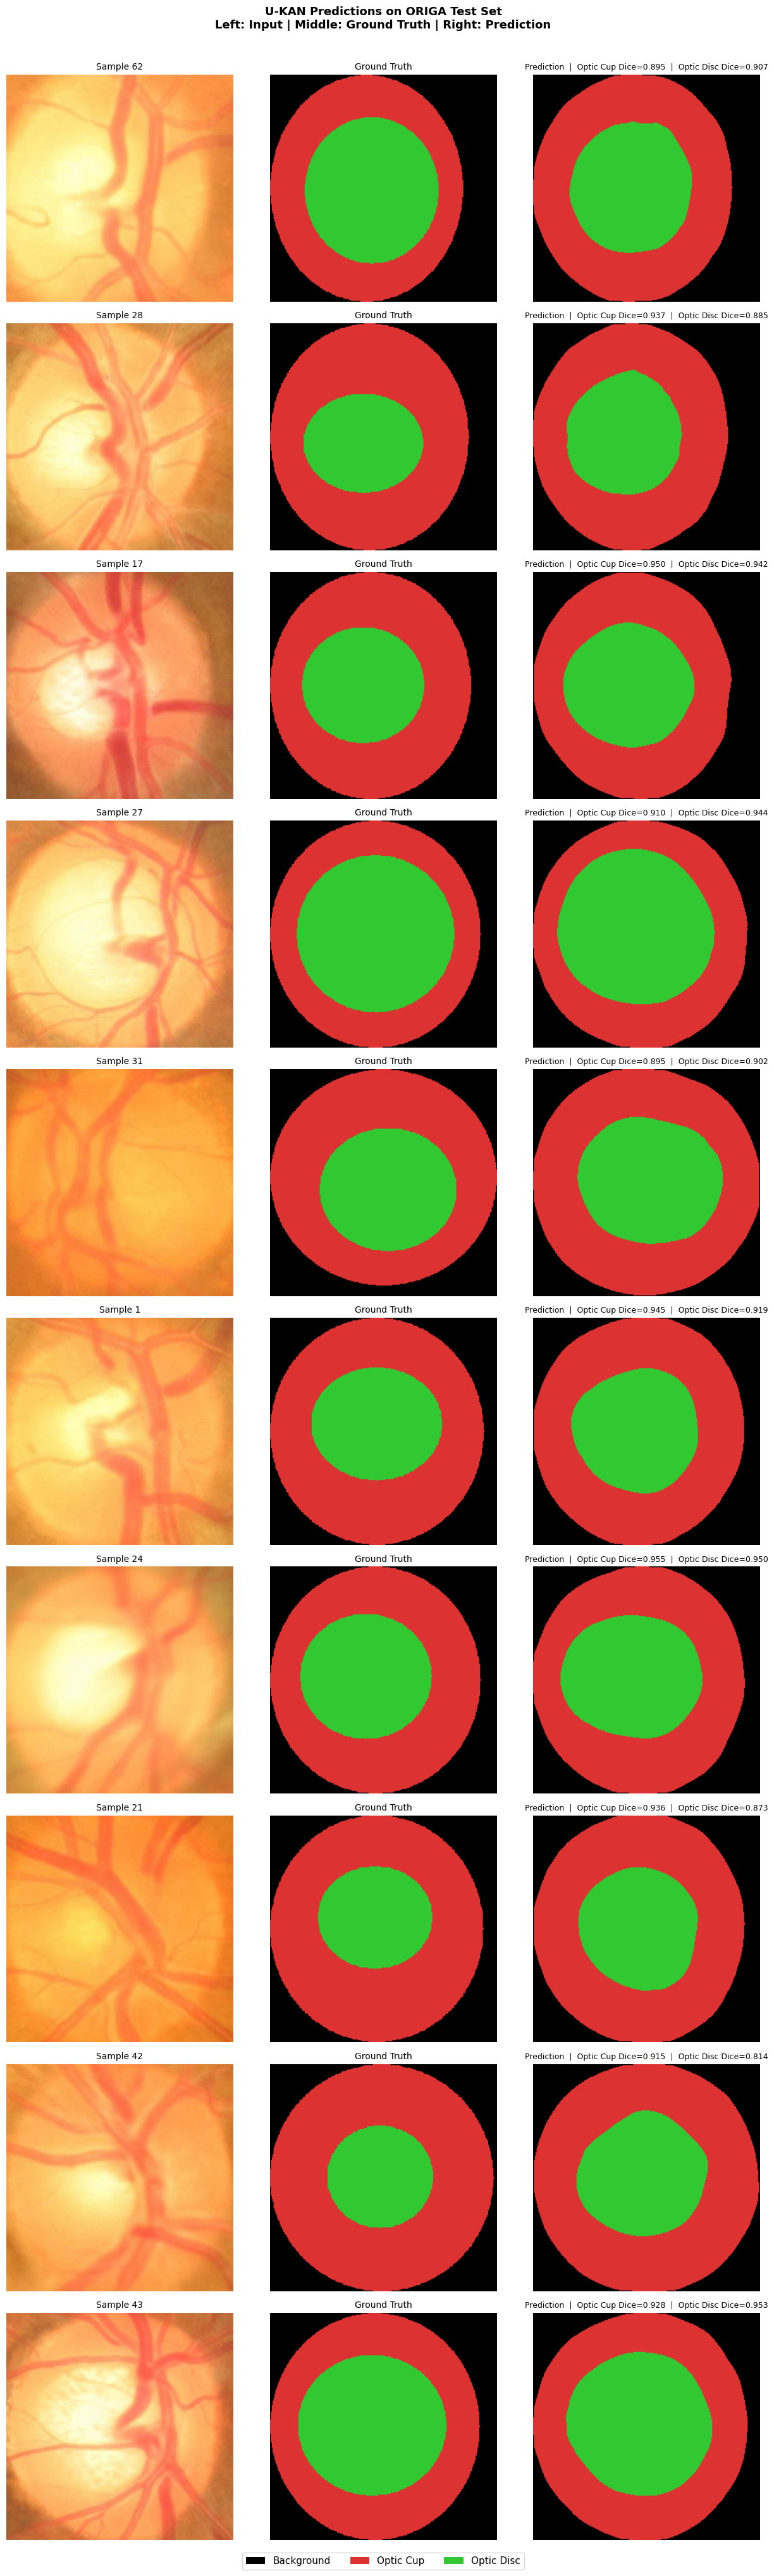

Saved to /content/ORIGA_predictions.png


In [52]:
# Cell 21: Visualize 10 test samples — Input | Ground Truth | Prediction
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_samples=10,
                          class_names=None, save_path="/content/ORIGA_predictions.png"):
    model.eval()
    indices = random.sample(range(len(dataset)), num_samples)
    mean_np = np.array([0.485, 0.456, 0.406])
    std_np  = np.array([0.229, 0.224, 0.225])

    # Color map: 0=black, 1=red (cup), 2=green (disc)
    CMAP_COLORS = np.array([
        [0,   0,   0],    # class 0 — background
        [220, 50,  50],   # class 1 — optic cup
        [50,  200, 50],   # class 2 — optic disc
    ], dtype=np.uint8)

    def colorize(mask_np):
        h, w   = mask_np.shape
        canvas = np.zeros((h, w, 3), dtype=np.uint8)
        for c_idx, color in enumerate(CMAP_COLORS):
            canvas[mask_np == c_idx] = color
        return canvas

    fig, axes = plt.subplots(num_samples, 3, figsize=(13, 4 * num_samples))
    fig.suptitle("U-KAN Predictions on ORIGA Test Set\n"
                 "Left: Input | Middle: Ground Truth | Right: Prediction",
                 fontsize=13, fontweight='bold', y=1.005)

    for row, idx in enumerate(indices):
        image, mask = dataset[idx]

        # Run model
        pred_logits = model(image.unsqueeze(0).to(device))
        pred_mask   = torch.argmax(pred_logits, dim=1).squeeze(0).cpu().numpy()
        gt_mask     = mask.cpu().numpy()

        # Denormalize image
        img_np = (image.permute(1, 2, 0).cpu().numpy() * std_np + mean_np).clip(0, 1)

        # Colorized masks
        gt_color   = colorize(gt_mask)
        pred_color = colorize(pred_mask)

        # Compute per-sample Dice for cup + disc
        sample_dice = []
        for c in range(1, NUM_CLASSES):
            p = (pred_mask == c)
            g = (gt_mask   == c)
            d = (2*(p & g).sum() + 1e-6) / (p.sum() + g.sum() + 1e-6)
            sample_dice.append(f"{CLASS_NAMES[c]} Dice={d:.3f}")

        # Plot
        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Sample {idx}", fontsize=10)
        axes[row, 0].axis('off')

        axes[row, 1].imshow(gt_color)
        axes[row, 1].set_title("Ground Truth", fontsize=10)
        axes[row, 1].axis('off')

        axes[row, 2].imshow(pred_color)
        axes[row, 2].set_title("Prediction  |  " + "  |  ".join(sample_dice), fontsize=9)
        axes[row, 2].axis('off')

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='black',     label='Background'),
                       Patch(facecolor='#DC3232',   label='Optic Cup'),
                       Patch(facecolor='#32C832',   label='Optic Disc')]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               fontsize=11, bbox_to_anchor=(0.5, -0.01))

    plt.tight_layout()
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")


visualize_predictions(best_model, test_ds, DEVICE,
                      num_samples=10, class_names=CLASS_NAMES)

In [53]:
# Cell 22: Automatic written interpretation of results
def interpret_results(test_metrics, history, num_classes, class_names):
    dice   = test_metrics["dice"]
    iou    = test_metrics["iou"]
    prec   = test_metrics["precision"]
    rec    = test_metrics["recall"]
    f1     = test_metrics["f1"]
    acc    = test_metrics["accuracy"]

    mean_dice = np.mean(dice[1:])
    mean_iou  = np.mean(iou[1:])
    epochs_ran = len(history["train_loss"])

    # Grade overall performance
    if mean_dice >= 0.85:
        overall_grade = "excellent"
    elif mean_dice >= 0.75:
        overall_grade = "good"
    elif mean_dice >= 0.60:
        overall_grade = "moderate"
    else:
        overall_grade = "low — the model needs more training or tuning"

    # Overfitting check
    final_train = history["train_loss"][-1]
    final_val   = history["val_loss"][-1]
    gap         = final_val - final_train
    if gap > 0.1:
        overfit_note = (f"There is a noticeable gap between train loss ({final_train:.4f}) "
                        f"and val loss ({final_val:.4f}), suggesting mild overfitting. "
                        f"Consider adding dropout or more augmentation.")
    else:
        overfit_note = (f"Train loss ({final_train:.4f}) and val loss ({final_val:.4f}) "
                        f"are close, indicating the model generalised well.")

    # Per-class analysis
    class_lines = []
    for c in range(1, num_classes):   # skip background
        name = class_names[c]
        note = ""
        if dice[c] >= 0.85:
            note = "strong segmentation"
        elif dice[c] >= 0.70:
            note = "acceptable segmentation"
        else:
            note = "poor segmentation — likely due to class imbalance or small region size"

        if prec[c] > rec[c] + 0.1:
            pr_note = "Precision > Recall: the model is conservative — it misses some regions but rarely predicts falsely."
        elif rec[c] > prec[c] + 0.1:
            pr_note = "Recall > Precision: the model is aggressive — it captures most regions but over-predicts boundaries."
        else:
            pr_note = "Precision and Recall are balanced."

        class_lines.append(
            f"  • {name}: Dice={dice[c]:.4f} | IoU={iou[c]:.4f} | "
            f"Prec={prec[c]:.4f} | Rec={rec[c]:.4f} | F1={f1[c]:.4f}\n"
            f"    → {note}. {pr_note}"
        )

    print("\n" + "="*65)
    print("         RESULT INTERPRETATION — U-KAN on ORIGA")
    print("="*65)
    print(f"\n[TRAINING]")
    print(f"  Model trained for {epochs_ran} epochs.")
    print(f"  {overfit_note}")

    print(f"\n[OVERALL PERFORMANCE]")
    print(f"  Pixel Accuracy : {acc:.4f}  "
          f"({'high — but expected as background dominates' if acc > 0.90 else 'moderate'})")
    print(f"  Mean Dice (fg) : {mean_dice:.4f}  → Overall quality is {overall_grade}.")
    print(f"  Mean IoU  (fg) : {mean_iou:.4f}")

    print(f"\n[PER-CLASS BREAKDOWN]")
    for line in class_lines:
        print(line)

    print(f"\n[CLINICAL RELEVANCE]")
    print(f"  The Optic Cup/Disc ratio (CDR) is the key glaucoma indicator.")
    print(f"  Accurate Optic Cup segmentation (Dice={dice[1]:.4f}) is harder due to")
    print(f"  its small size and fuzzy boundaries — any Dice above 0.80 is clinically useful.")
    print(f"  Optic Disc (Dice={dice[2]:.4f}) is typically easier to segment.")
    print(f"  A well-performing model on both enables automated CDR estimation.")

    print("\n" + "="*65)

interpret_results(test_metrics, history_origa, NUM_CLASSES, CLASS_NAMES)


         RESULT INTERPRETATION — U-KAN on ORIGA

[TRAINING]
  Model trained for 71 epochs.
  Train loss (0.1636) and val loss (0.1702) are close, indicating the model generalised well.

[OVERALL PERFORMANCE]
  Pixel Accuracy : 0.9109  (high — but expected as background dominates)
  Mean Dice (fg) : 0.8928  → Overall quality is excellent.
  Mean IoU  (fg) : 0.8072

[PER-CLASS BREAKDOWN]
  • Optic Cup: Dice=0.9017 | IoU=0.8216 | Prec=0.8939 | Rec=0.9122 | F1=0.9017
    → strong segmentation. Precision and Recall are balanced.
  • Optic Disc: Dice=0.8840 | IoU=0.7929 | Prec=0.8771 | Rec=0.8974 | F1=0.8840
    → strong segmentation. Precision and Recall are balanced.

[CLINICAL RELEVANCE]
  The Optic Cup/Disc ratio (CDR) is the key glaucoma indicator.
  Accurate Optic Cup segmentation (Dice=0.9017) is harder due to
  its small size and fuzzy boundaries — any Dice above 0.80 is clinically useful.
  Optic Disc (Dice=0.8840) is typically easier to segment.
  A well-performing model on both e